<center><h1>Velasco_Djovan_HW2</h1></center>
<br>
<br>

Name: Djovan Velasco
<br>
Github Username: Djovan-Velasco
<br>
USC ID: 8082620160

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import tabulate

Get the Cycle Power Plant Data Set

In [92]:
cpp_data = pd.read_excel('../data/power_plant_data/Folds5x2_pp.xlsx', sheet_name = 'Sheet1')
cpp_data.columns = ['T', 'V', 'AP', 'RH', 'EP']
print(cpp_data.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/power_plant_data/Folds5x2_pp.xlsx'

### (b) Exploring the data

#### i. rows and columns

In [ ]:
print(cpp_data.shape)

(9568, 5)


There are 9568 rows which represent different hourly averages for each of the different variables we are tracking. The 5 columns represent Temperature (T), Ambient Pressure (AP), Relative Humidity (RH), Exhaust Vacuum (V), and net hourly electrical
energy output (EP) in which each column contains rows with the average readings for each of these metrics.

#### ii. pairwise scatterplots of all the varianbles

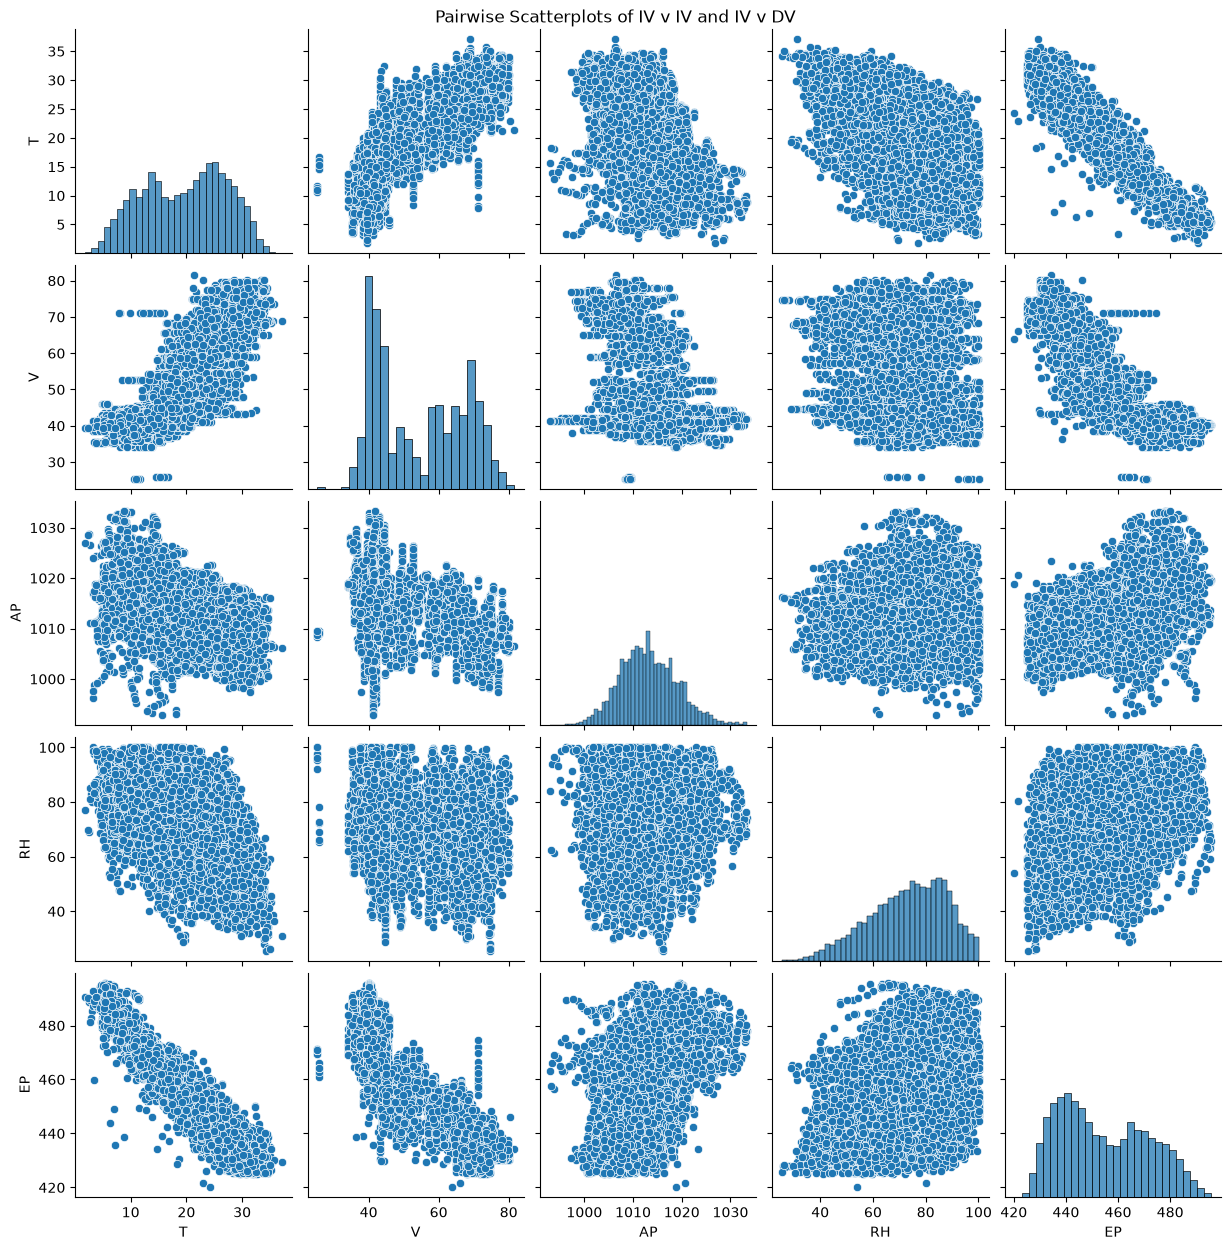

In [ ]:
sns.pairplot(cpp_data)
plt.suptitle('Pairwise Scatterplots of IV v IV and IV v DV', y = 1)
plt.show()

Predictors T and V show moderate positive correlation with each other, and moderately negative correlation with the response. The other 2 predictors have a very weak positive correlation with the response and almost no assocaiton with any other predictors. 

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [ ]:
sum_stats = cpp_data.describe().T
sum_stats['range'] = sum_stats['max'] - sum_stats['min']
sum_stats['IQR'] = sum_stats['75%'] - sum_stats['25%']
sum_stats = sum_stats[['mean', '50%', 'range', '25%', '75%', 'IQR']]
sum_stats.columns = ['Mean', 'Median', 'Range', 'Q1', 'Q3', 'IQR']
print(tabulate.tabulate(sum_stats, headers='keys', tablefmt='grid', showindex=True))

+----+-----------+----------+---------+-----------+---------+---------+
|    |      Mean |   Median |   Range |        Q1 |      Q3 |     IQR |
+====+===========+==========+=========+===========+=========+=========+
| T  |   19.6512 |   20.345 |   35.3  |   13.51   |   25.72 | 12.21   |
+----+-----------+----------+---------+-----------+---------+---------+
| V  |   54.3058 |   52.08  |   56.2  |   41.74   |   66.54 | 24.8    |
+----+-----------+----------+---------+-----------+---------+---------+
| AP | 1013.26   | 1012.94  |   40.41 | 1009.1    | 1017.26 |  8.16   |
+----+-----------+----------+---------+-----------+---------+---------+
| RH |   73.309  |   74.975 |   74.6  |   63.3275 |   84.83 | 21.5025 |
+----+-----------+----------+---------+-----------+---------+---------+
| EP |  454.365  |  451.55  |   75.5  |  439.75   |  468.43 | 28.68   |
+----+-----------+----------+---------+-----------+---------+---------+


### (c) Simple Linear Regression

Predictor: T has 42 outliers.
Predictor: V has 33 outliers.
Predictor: AP has 29 outliers.
Predictor: RH has 2 outliers.


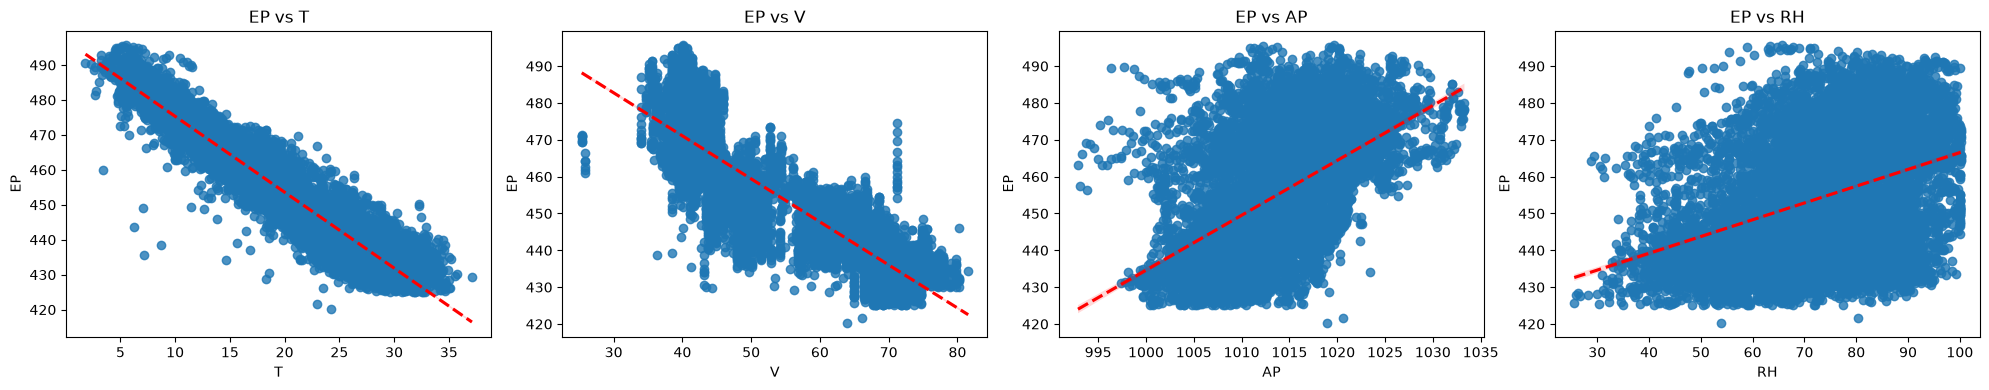

Predictor: T | Slope: -2.1713 | p-value: 0.0000e+00 | R2: 0.8989
Predictor: V | Slope: -1.1681 | p-value: 0.0000e+00 | R2: 0.7565
Predictor: AP | Slope: 1.4899 | p-value: 0.0000e+00 | R2: 0.2688
Predictor: RH | Slope: 0.4557 | p-value: 0.0000e+00 | R2: 0.1519


In [ ]:
response = 'EP'
predictors = [col for col in cpp_data.columns if col != response]

results = {}
clean_data = {}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for col in predictors:
  X = sm.add_constant(cpp_data[col])
  y = cpp_data[response]

  simple_fit = sm.OLS(y, X).fit()

  results[col] = {
      'coefficient': simple_fit.params[col],
      'p_value': simple_fit.pvalues[col],
      'r2_score': simple_fit.rsquared,
      'intercept': simple_fit.params['const'],
      'intercept_p_value': simple_fit.pvalues['const'],
  }
  influence = simple_fit.get_influence()
  std_resid = influence.resid_studentized_internal
    
  non_outliers = np.abs(std_resid) <= 3
    
  clean_cpp_data = cpp_data[non_outliers].copy()
  clean_data[col] = clean_cpp_data
    
  num_outliers = len(cpp_data) - len(clean_cpp_data)
  print(f"Predictor: {col} has {num_outliers} outliers.")
  
  sns.regplot(x=cpp_data[col], y=cpp_data['EP'], ax = axes[predictors.index(col)], line_kws={'color': 'red', 'linestyle': '--'})
  axes[predictors.index(col)].set_title(f'EP vs {col}')
plt.tight_layout()
plt.show()

for col, metrics in results.items():
  print(
      f'Predictor: {col} | Slope: {metrics["coefficient"]:.4f} | p-value:'
      f' {metrics["p_value"]:.4e} | R2: {metrics["r2_score"]:.4f}'
  )


Note: While outliers were identified and removed using standardized residuals for the purpose of the assignment, the models were not fit using the cleaned data because more investigation must be conducted before simply removing the outliers based on high standardized residual. 

Based on p-values each of these predictors appears to have a significant association with the response EP because their p-values are below 0.05. However, looking at the R^2 and the plots it seems that T and V explain much more of the variability and have a stronger association with EP than the other two predictors. However, this does not mean that we can't conclude that the others are insignificant, rather we must undergo further investigation to determine whether or not they do truly have a significant association with the response. 

### (d) Multiple Regression

In [ ]:
pred_mlr = sm.add_constant(cpp_data[['T', 'V', 'AP', 'RH']])
mlr_fit = sm.OLS(cpp_data['EP'], pred_mlr).fit()
print(mlr_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:13:11   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

Similarly to part c, we reject the null hypothesis for all predictors since all have p-values less than the 0.05 threshold. The r^2 for the overall model is very high, indicating that the model accounts for a very high percentage of the variability in EP. The coefficients for predictors T and V increased while those for AP and RH decreased. 

### (e) 1c Compare to 1d

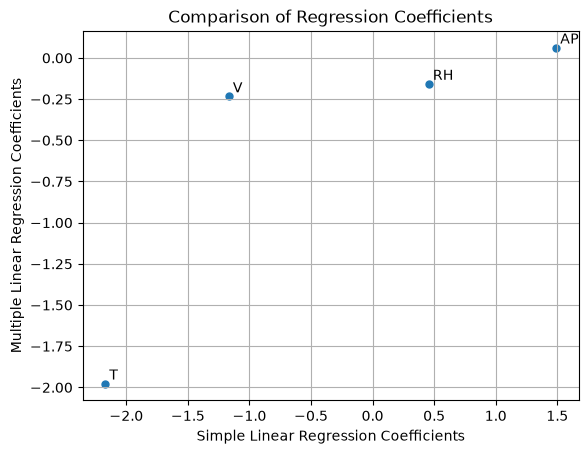

In [ ]:
mlr_coefs = mlr_fit.params.drop('const')

simple_coefs_list = [results[p]['coefficient'] for p in predictors]
mlr_coefs_list = [mlr_coefs[p] for p in predictors]

plt.scatter(simple_coefs_list, mlr_coefs_list, s=25)

for p in predictors:
    plt.annotate(
        p, 
        (results[p]['coefficient'], mlr_coefs[p]), 
        xytext=(3, 3),
        textcoords='offset points'
    )

plt.xlabel('Simple Linear Regression Coefficients')
plt.ylabel('Multiple Linear Regression Coefficients')
plt.title('Comparison of Regression Coefficients')
plt.grid(True)
plt.show()

### (f) Nonlinear Association

In [ ]:
cpp_scaled = cpp_data.copy()
for col in predictors:
    cpp_scaled[col] = (cpp_data[col] - cpp_data[col].mean()) / cpp_data[col].std()

for col in predictors:
    formula = f"EP ~ {col} + np.power({col}, 2) + np.power({col}, 3)"
    
    poly_fit = smf.ols(formula=formula, data=cpp_scaled).fit()
    
    print(f"Polynomial Regression: EP ~ {col}")
    print(poly_fit.summary().tables[1])
    print("\n")

Polynomial Regression: EP ~ T
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        452.7081      0.074   6085.240      0.000     452.562     452.854
T                -18.1075      0.108   -167.160      0.000     -18.320     -17.895
np.power(T, 2)     1.8080      0.054     33.381      0.000       1.702       1.914
np.power(T, 3)     1.1071      0.049     22.594      0.000       1.011       1.203


Polynomial Regression: EP ~ V
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        451.2137      0.144   3124.596      0.000     450.931     451.497
V                -15.8881      0.185    -85.722      0.000     -16.251     -15.525
np.power(V, 2)     3.0969      0.125     24.714      0.000       2.851       3.343
np.power(V, 3)     0.2757

There is evidence of non-linear association between every predictor and the response. For T, V, and AP, both the quadratic and cubic terms are statistically significant with p below 0.05. For RH, while the quadratic term is not significant, the cubic term is significant, since the higher order is significant we can indicate a non-linear relationship.

### (g) Interactions of Predictors

In [ ]:
interactions = 'EP ~ T*V + T*AP + T*RH + V*AP + V*RH + AP*RH'
interaction_model = smf.ols(formula=interactions, data=cpp_data).fit()
print(interaction_model.pvalues)

Intercept     3.231607e-18
T             6.701873e-02
V             1.371251e-08
T:V          3.333358e-117
AP            4.735732e-02
T:AP          4.520509e-01
RH            4.225213e-02
T:RH          1.216944e-10
V:AP          2.877026e-07
V:RH          8.619366e-02
AP:RH         3.360557e-02
dtype: float64


The interactions of T:V, T:RH, V:AP, and AP:RH are the only significant interaction terms with p-values below 0.05. 

### (h) Improvement

In [ ]:
train, test = train_test_split(cpp_data, test_size=0.3, random_state=42)

base_fit = smf.ols('EP ~ T + V + AP + RH', data=train).fit()
base_train_mse = mean_squared_error(train['EP'], base_fit.predict(train))
base_test_mse = mean_squared_error(test['EP'], base_fit.predict(test))

improvement_formula = 'EP ~ T + V + AP + RH + np.power(T,2) + np.power(V,2) + np.power(AP,2) + np.power(RH,2) + T:V + T:AP + T:RH + V:AP + V:RH + AP:RH'
improved_fit = smf.ols(improvement_formula, data=train).fit()
print(improved_fit.summary())

updated_improved_formula = 'EP ~ T + AP + RH + np.power(T,2) + np.power(AP,2) + np.power(RH,2) + T:V + T:RH + V:AP + V:RH + AP:RH'
updated_improved_fit = smf.ols(updated_improved_formula, data=train).fit()
updated_train_mse = mean_squared_error(train['EP'], updated_improved_fit.predict(train))
updated_test_mse = mean_squared_error(test['EP'], updated_improved_fit.predict(test))

print(f"Base Train MSE: {base_train_mse:.3f}")
print(f"Base Test MSE: {base_test_mse:.3f}")
print(f"Updated Improved Train MSE: {updated_train_mse:.3f}")
print(f"Updated Improved Test MSE: {updated_test_mse:.3f}")

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:13:12   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -7664.9809   1429.568     

### (i) KNN

Best k (Normalized): 4, Lowest Test MSE: 14.306
Best k (Raw): 5, Lowest Test MSE: 15.727


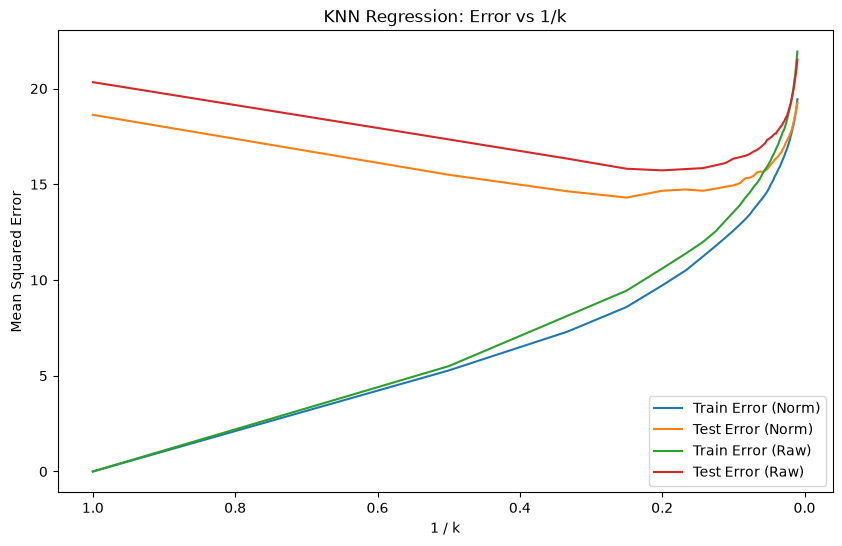

In [ ]:
train_x, train_y = train[['T', 'V', 'AP', 'RH']], train['EP']
test_x, test_y = test[['T', 'V', 'AP', 'RH']], test['EP']

scale = StandardScaler()
train_x_norm = scale.fit_transform(train_x)
test_x_norm = scale.transform(test_x)

k_values = list(range(1, 101))
test_errors_raw, test_errors_norm = [], []
train_errors_raw, train_errors_norm = [], []

for k in k_values:
    knn_norm = KNeighborsRegressor(n_neighbors=k)
    knn_norm.fit(train_x_norm, train_y)
    train_errors_norm.append(mean_squared_error(train_y, knn_norm.predict(train_x_norm)))
    test_errors_norm.append(mean_squared_error(test_y, knn_norm.predict(test_x_norm)))
    
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(train_x, train_y)
    train_errors_raw.append(mean_squared_error(train_y, knn_raw.predict(train_x)))
    test_errors_raw.append(mean_squared_error(test_y, knn_raw.predict(test_x)))

best_k_norm = k_values[np.argmin(test_errors_norm)]
best_k_raw = k_values[np.argmin(test_errors_raw)]
print(f"Best k (Normalized): {best_k_norm}, Lowest Test MSE: {min(test_errors_norm):.3f}")
print(f"Best k (Raw): {best_k_raw}, Lowest Test MSE: {min(test_errors_raw):.3f}")

plt.figure(figsize=(10, 6))
plt.plot(1/np.array(k_values), train_errors_norm, label='Train Error (Norm)')
plt.plot(1/np.array(k_values), test_errors_norm, label='Test Error (Norm)')
plt.plot(1/np.array(k_values), train_errors_raw, label='Train Error (Raw)')
plt.plot(1/np.array(k_values), test_errors_raw, label='Test Error (Raw)')
plt.xlabel('1 / k')
plt.ylabel('Mean Squared Error')
plt.title('KNN Regression: Error vs 1/k')
plt.legend()
plt.gca().invert_xaxis() #
plt.show()

### (j ) Compare KNN and Linear

The updated OLS model had a test error of 18.706 which does not beat out the minimized mse of our lowest KNN model the normalized with k=4 with an mse of 14.306.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible model would be better than an inflexible model because the large n and low number of predictors would help to guard against overfitting and generally create more accurate predictions than an inflexible one.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

In this scenario, a flexible method would be worse because with small n and large p it will likely overfit the data. An inflexible here keeps variance low on limited data. 

### (c) The relationship between the predictors and response is highly non-linear.

A flexibile model would be better, inflexibile models like linear-regression expect simple linear relationships between the predictors and response so a flexibile model would be able to handle and accurately predict with a non-linear relationship. The inflexibile would have high bias whereas the flexibile would fit to the shape of the data best.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

With lots of noise, the flexibile model is not preffered. It will try to overfit the data and capture all the noise, where an inflexbile model would provide a smoother fit. 

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [ ]:
data = {
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']
}
df = pd.DataFrame(data, index=[1, 2, 3, 4, 5, 6])
test_point = np.array([0, 0, 0])

df['Distance'] = np.sqrt(((df[['X1', 'X2', 'X3']] - test_point)**2).sum(axis=1))

print(df[['Distance', 'Y']].sort_values(by='Distance'))
print("\n")

   Distance      Y
5  1.414214  Green
6  1.732051    Red
2  2.000000    Red
4  2.236068  Green
1  3.000000    Red
3  3.162278    Red




### (b) What is our prediction with K = 1? Why?

In [ ]:
k1_nearest = df.nsmallest(1, 'Distance')
k1_pred = k1_nearest['Y'].mode()[0]
print(k1_pred)

Green


### (c) What is our prediction with K = 3? Why?

In [ ]:
k3_nearest = df.nsmallest(3, 'Distance')
k3_pred = k3_nearest['Y'].mode()[0]
print(k3_pred)

Red


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

If the boundary is highly non linear we would expect the best k to be small since smaller k-values indicate more flexibile models. A more flexibile model in this case would be able to accurately capture the non linear relationship without smoothing the trends. 

In [ ]:
!git init
!git add README.md
!git checkout -b dev
!git add Velasco_Djovan_HW2.ipynb
!git commit -m "Add notebook to dev branch"
!git branch -M main
!git remote add origin https://github.com/Djovan-Velasco/552_hw2_repo.git
!git push -u origin main

Initialized empty Git repository in /Users/djovanvelasco/552_hw2/.git/
fatal: pathspec 'README.md' did not match any files
Switched to a new branch 'dev'
[dev (root-commit) 7fea855] Add notebook to dev branch
 1 file changed, 493 insertions(+)
 create mode 100644 Velasco_Djovan_HW2.ipynb
Enumerating objects: 3, done.
Counting objects: 100% (3/3), done.
Delta compression using up to 10 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 3.97 KiB | 3.97 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
To https://github.com/Djovan-Velasco/552_hw2_repo.git
 * [new branch]      main -> main
branch 'main' set up to track 'origin/main'.


In [ ]:
!mkdir -p notebook data/power_plant_data
!mv Velasco_Djovan_HW2.ipynb notebook/
!cp /Users/djovanvelasco/552_hw2/Folds5x2_pp.xlsx data/power_plant_data/
!touch _gitignore requirements.txt README.md
!git add .
!git commit -m "Reorganize repo structure"
!git push

[main 7a95920] Reorganize repo structure
 6 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 Folds5x2_pp.xlsx
 create mode 100644 README.md
 create mode 100644 _gitignore
 create mode 100644 data/power_plant_data/Folds5x2_pp.xlsx
 rename Velasco_Djovan_HW2.ipynb => notebook/Velasco_Djovan_HW2.ipynb (100%)
 create mode 100644 requirements.txt
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 10 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (6/6), 1.93 MiB | 2.41 MiB/s, done.
Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
To https://github.com/Djovan-Velasco/552_hw2_repo.git
   7fea855..7a95920  main -> main
